<a href="https://colab.research.google.com/github/alizaib-basra/AI-ML-/blob/main/Task2-Stock-Prediction/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Stock Price Prediction using Machine Learning
## Task 2 – AI/ML Internship Project

---

### 🎯 Problem Statement
Stock markets are highly dynamic environments where prices fluctuate based on a multitude of factors. The goal of this project is to **predict the next day's closing price** of a selected stock using historical OHLCV (Open, High, Low, Close, Volume) data.

### 🏁 Objective
- Fetch real-world historical stock data using the `yfinance` API
- Perform exploratory data analysis and feature engineering
- Train two machine learning models: **Linear Regression** and **Random Forest Regressor**
- Compare predicted vs actual closing prices using visualizations
- Evaluate models using standard regression metrics (MAE, RMSE, R²)

### 📦 Stock Selected: **Apple Inc. (AAPL)**

---
## 📚 Section 1: Import Libraries

In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Data Fetching ────────────────────────────────────────────────────────────
import yfinance as yf

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📥 Section 2: Load Dataset via yfinance API

We use the `yfinance` library to download 5 years of daily OHLCV data for **Apple Inc. (AAPL)** directly from Yahoo Finance.

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
TICKER   = 'AAPL'          # Stock ticker symbol
START    = '2019-01-01'    # Historical start date
END      = '2024-12-31'    # Historical end date

# ── Fetch Data ────────────────────────────────────────────────────────────────
print(f' Fetching data for {TICKER} from {START} to {END} ...')
raw_df = yf.download(TICKER, start=START, end=END, auto_adjust=True)

# Flatten MultiIndex columns if present (yfinance v0.2+)
if isinstance(raw_df.columns, pd.MultiIndex):
    raw_df.columns = raw_df.columns.get_level_values(0)

print(f'Downloaded {len(raw_df)} trading days of data.')
print(f' Date range : {raw_df.index[0].date()} → {raw_df.index[-1].date()}')
raw_df.head()

 Fetching data for AAPL from 2019-01-01 to 2024-12-31 ...


[*********************100%***********************]  1 of 1 completed

Downloaded 1509 trading days of data.
 Date range : 2019-01-02 → 2024-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.469212,37.689872,36.593696,36.750293,148158800
2019-01-03,33.736996,34.574548,33.691914,34.161702,365248800
2019-01-04,35.177208,35.246017,34.118999,34.292203,234428400
2019-01-07,35.098900,35.312442,34.617248,35.281596,219111200
2019-01-08,35.768009,36.021887,35.238905,35.485661,164101200


In [3]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print('📋 Dataset Shape:', raw_df.shape)
print('\n📊 Column Data Types:')
print(raw_df.dtypes)
print('\n🔍 Missing Values:')
print(raw_df.isnull().sum())

📋 Dataset Shape: (1509, 5)

📊 Column Data Types:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

🔍 Missing Values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [4]:
# ── Descriptive Statistics ────────────────────────────────────────────────────
raw_df.describe().round(2)

Price,Close,High,Low,Open,Volume
count,1509.00,1509.00,1509.00,1509.00,1.509000e+03
mean,134.36,135.69,132.87,134.21,9.420399e+07
std,53.84,54.22,53.37,53.78,5.232393e+07
min,33.74,34.57,33.69,34.16,2.323470e+07
25%,88.31,89.67,87.69,88.35,5.914450e+07
50%,142.68,144.21,140.99,142.53,8.153200e+07
75%,171.35,172.82,169.50,171.19,1.124244e+08
max,257.38,258.45,255.99,256.55,4.265100e+08


---
## 🔍 Section 3: Exploratory Data Analysis (EDA)

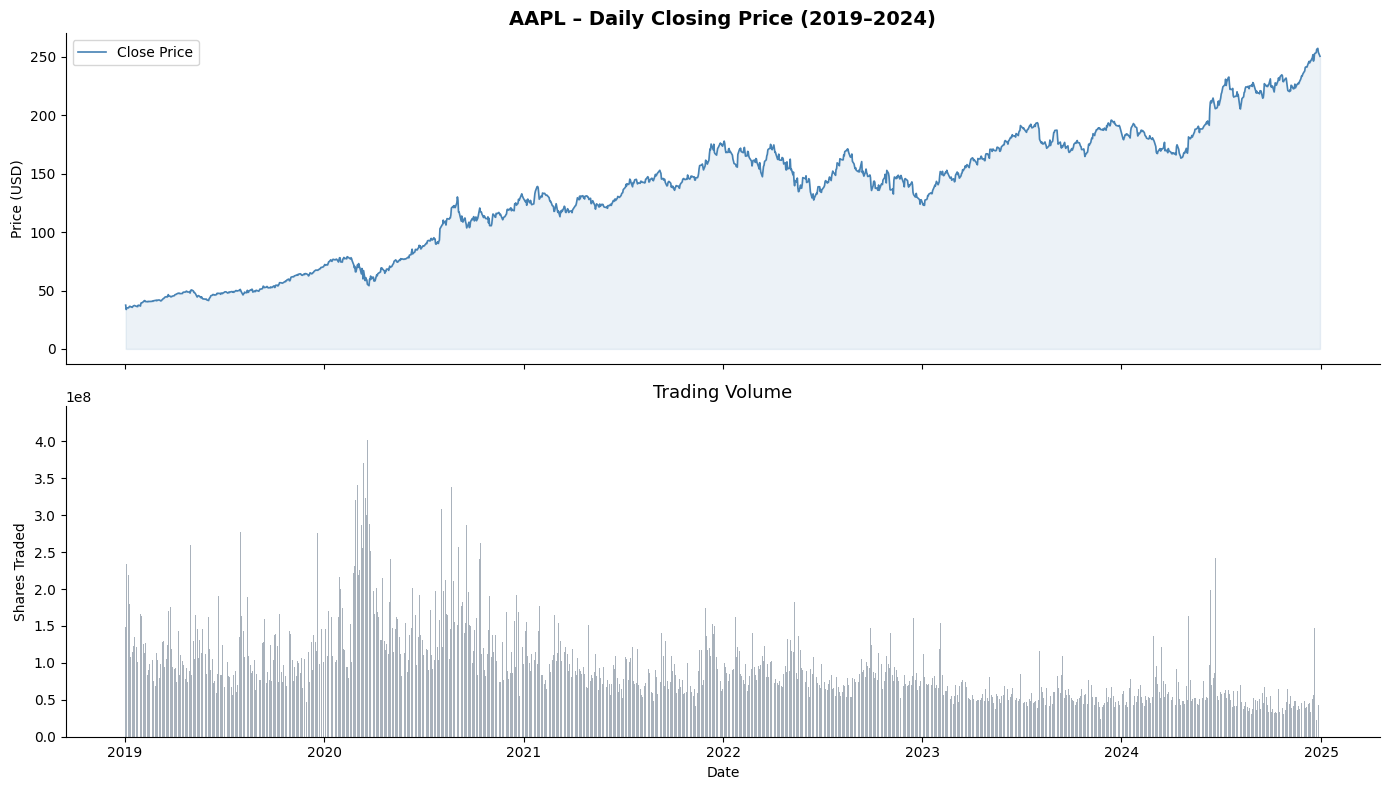

✅ Figure saved: eda_price_volume.png


In [5]:
# ── 3.1 Closing Price History ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Closing price
axes[0].plot(raw_df.index, raw_df['Close'], color='steelblue', linewidth=1.2, label='Close Price')
axes[0].fill_between(raw_df.index, raw_df['Close'], alpha=0.1, color='steelblue')
axes[0].set_title(f'{TICKER} – Daily Closing Price (2019–2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Volume
axes[1].bar(raw_df.index, raw_df['Volume'], color='slategray', alpha=0.6, width=1)
axes[1].set_title('Trading Volume', fontsize=13)
axes[1].set_ylabel('Shares Traded')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_price_volume.png')

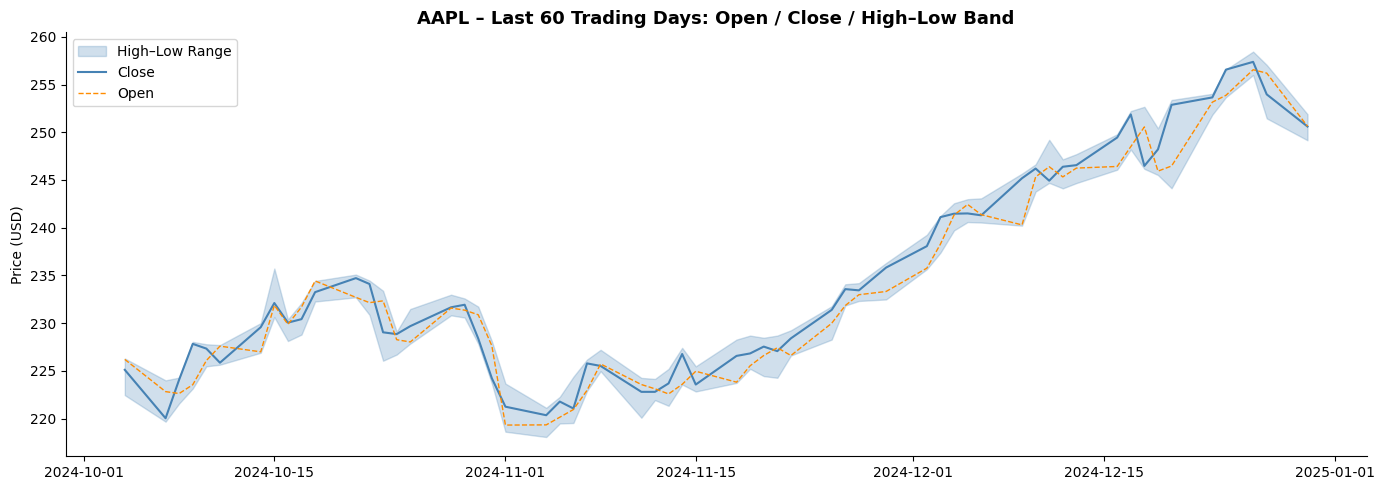

Figure saved: eda_ohlc_recent.png


In [6]:
# ── 3.2 OHLC Candlestick-style Overview ───────────────────────────────────────
# Plot the last 60 trading days with High/Low bands
recent = raw_df.tail(60).copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(recent.index, recent['Low'], recent['High'],
                alpha=0.25, color='steelblue', label='High–Low Range')
ax.plot(recent.index, recent['Close'], color='steelblue', linewidth=1.5, label='Close')
ax.plot(recent.index, recent['Open'],  color='darkorange', linewidth=1, linestyle='--', label='Open')
ax.set_title(f'{TICKER} – Last 60 Trading Days: Open / Close / High–Low Band', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_ohlc_recent.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_ohlc_recent.png')

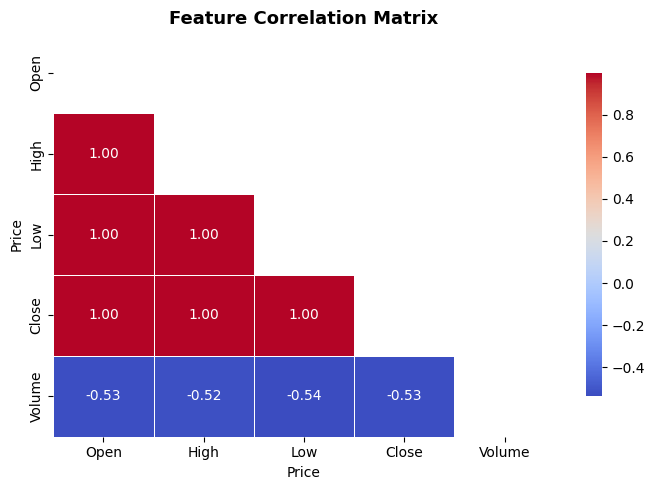

Figure saved: eda_correlation.png


In [7]:
# ── 3.3 Correlation Heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr = raw_df[['Open','High','Low','Close','Volume']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_correlation.png')

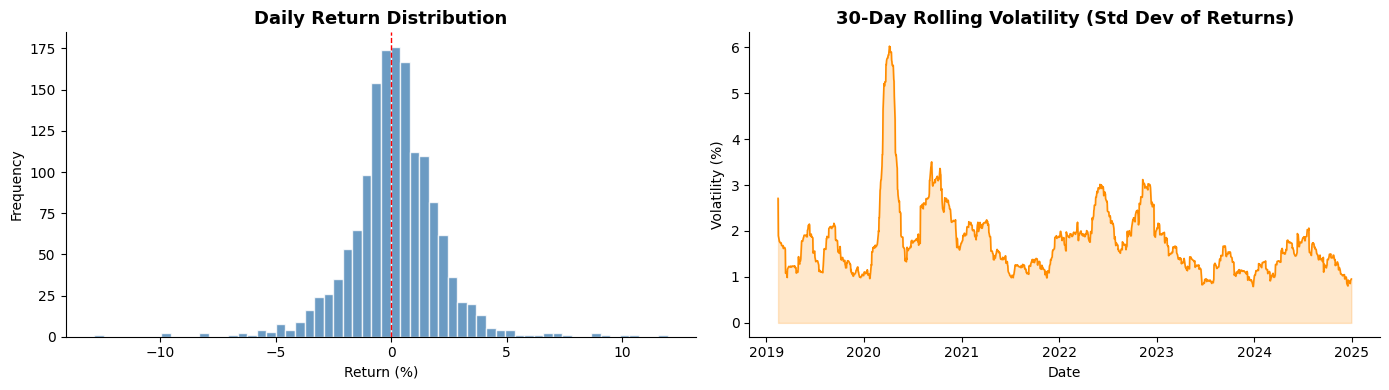

Figure saved: eda_returns.png


In [8]:
# ── 3.4 Daily Return Distribution ────────────────────────────────────────────
raw_df['Daily_Return'] = raw_df['Close'].pct_change() * 100   # percentage

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(raw_df['Daily_Return'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Daily Return Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Frequency')

# Rolling 30-day volatility
rolling_vol = raw_df['Daily_Return'].rolling(30).std()
axes[1].plot(raw_df.index, rolling_vol, color='darkorange', linewidth=1.2)
axes[1].fill_between(raw_df.index, rolling_vol, alpha=0.2, color='darkorange')
axes[1].set_title('30-Day Rolling Volatility (Std Dev of Returns)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility (%)')

plt.tight_layout()
plt.savefig('eda_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_returns.png')

---
## 🛠️ Section 4: Feature Engineering

We engineer several **technical indicator** features to enrich the raw OHLCV data and provide the models with more predictive signal:

| Feature | Description |
|---|---|
| `MA_5`, `MA_20` | 5-day and 20-day moving averages of Close |
| `Std_5` | 5-day rolling standard deviation |
| `Daily_Return` | Day-over-day percentage change in Close |
| `Price_Range` | High − Low (intra-day spread) |
| `Lag_1`, `Lag_2`, `Lag_3` | Previous 1/2/3 day closing prices |
| `Volume_Change` | Day-over-day volume percentage change |

> **Target variable**: Next day's `Close` price (`Target_Close` = `Close` shifted by –1)

In [9]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add technical indicator features and the prediction target."""
    d = df.copy()

    # ── Moving Averages ───────────────────────────────────────────────────────
    d['MA_5']  = d['Close'].rolling(5).mean()
    d['MA_20'] = d['Close'].rolling(20).mean()

    # ── Volatility ────────────────────────────────────────────────────────────
    d['Std_5'] = d['Close'].rolling(5).std()

    # ── Daily Return ──────────────────────────────────────────────────────────
    d['Daily_Return'] = d['Close'].pct_change() * 100

    # ── Price Range (Intra-day spread) ────────────────────────────────────────
    d['Price_Range'] = d['High'] - d['Low']

    # ── Lag Features (previous closing prices) ────────────────────────────────
    for lag in [1, 2, 3]:
        d[f'Lag_{lag}'] = d['Close'].shift(lag)

    # ── Volume Change ─────────────────────────────────────────────────────────
    d['Volume_Change'] = d['Volume'].pct_change() * 100

    # ── Target: next day's closing price ─────────────────────────────────────
    d['Target_Close'] = d['Close'].shift(-1)

    return d


df = engineer_features(raw_df)

# Drop rows with NaN (from rolling windows and shifts)
df.dropna(inplace=True)

print(f'   Feature engineering complete.')
print(f'   Rows after dropping NaN: {len(df)}')
print(f'   Total features          : {len(df.columns)}')
df[['Close','MA_5','MA_20','Std_5','Daily_Return',
    'Price_Range','Lag_1','Lag_2','Lag_3',
    'Volume_Change','Target_Close']].head()

   Feature engineering complete.
   Rows after dropping NaN: 1489
   Total features          : 15


Price,Close,MA_5,MA_20,Std_5,Daily_Return,Price_Range,Lag_1,Lag_2,Lag_3,Volume_Change,Target_Close
Date,,,,,,,,,,,
2019-01-30,39.208370,37.331116,36.432942,1.140554,6.833450,1.404620,36.700462,37.084835,37.431236,46.943771,39.490723
2019-01-31,39.490723,37.983125,36.534018,1.277772,0.720133,1.053466,39.208370,36.700462,37.084835,-33.333770,39.509693
2019-02-01,39.509693,38.398817,36.822653,1.386780,0.048038,0.723665,39.490723,39.208370,36.700462,-19.812418,40.631966
2019-02-04,40.631966,39.108243,37.095391,1.452293,2.840499,1.039230,39.509693,39.490723,39.208370,-3.589434,41.327168
2019-02-05,41.327168,40.033584,37.406804,0.905753,1.710973,0.647738,40.631966,39.509693,39.490723,14.624629,41.341412


---
## ✂️ Section 5: Data Splitting & Scaling

We use a **chronological 80/20 train-test split** (no shuffling) to avoid data leakage — the model must never see future data during training.

In [11]:
# ── Define Features & Target ──────────────────────────────────────────────────
FEATURES = ['Open', 'High', 'Low', 'Volume',
            'MA_5', 'MA_20', 'Std_5',
            'Daily_Return', 'Price_Range',
            'Lag_1', 'Lag_2', 'Lag_3',
            'Volume_Change']

TARGET = 'Target_Close'

X = df[FEATURES].values
y = df[TARGET].values
dates = df.index

# ── Chronological Train-Test Split (80 / 20) ──────────────────────────────────
split_idx = int(len(X) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test       = dates[split_idx:]

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'Train period     : {dates[0].date()} → {dates[split_idx-1].date()}')
print(f'Test  period     : {dates[split_idx].date()} → {dates[-1].date()}')

# ── Feature Scaling (StandardScaler fitted on train only) ─────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)          # transform test using train stats

print('\n Scaling complete (fitted on training data only to prevent leakage).')

Training samples : 1191
Testing  samples : 298
Train period     : 2019-01-30 → 2023-10-20
Test  period     : 2023-10-23 → 2024-12-27

 Scaling complete (fitted on training data only to prevent leakage).


---
## 🤖 Section 6: Model Training

We train two regression models and compare their performance:

1. **Linear Regression** – a simple baseline that models a linear relationship between features and target.
2. **Random Forest Regressor** – an ensemble of decision trees that captures non-linear patterns.

In [12]:
# ── 6.1 Linear Regression ─────────────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print(' Linear Regression trained.')

# ── 6.2 Random Forest Regressor ───────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200,       # number of trees
    max_depth=10,           # limit depth to prevent overfitting
    min_samples_leaf=4,     # each leaf must have at least 4 samples
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
print(' Random Forest trained.')

 Linear Regression trained.
 Random Forest trained.


---
## 📊 Section 7: Model Evaluation

In [13]:
def evaluate(name, y_true, y_pred):
    """Compute and print MAE, RMSE, and R² for a model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
    print('-' * 57)
    print(f"{name:<25} {mae:>10.4f} {rmse:>10.4f} {r2:>10.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


print('═' * 57)
print('                  MODEL EVALUATION RESULTS')
print('═' * 57)

lr_results = evaluate('Linear Regression', y_test, lr_preds)
print()
rf_results = evaluate('Random Forest',     y_test, rf_preds)
print('═' * 57)

# Summary table
results_df = pd.DataFrame([lr_results, rf_results]).set_index('Model')
print('\n📋 Summary Table:')
results_df.round(4)

═════════════════════════════════════════════════════════
                  MODEL EVALUATION RESULTS
═════════════════════════════════════════════════════════
Model                            MAE       RMSE         R²
---------------------------------------------------------
Linear Regression             2.1899     2.9171     0.9860

Model                            MAE       RMSE         R²
---------------------------------------------------------
Random Forest                17.5418    25.1907    -0.0430
═════════════════════════════════════════════════════════

📋 Summary Table:


,MAE,RMSE,R2
Model,,,
Linear Regression,2.1899,2.9171,0.986
Random Forest,17.5418,25.1907,-0.043


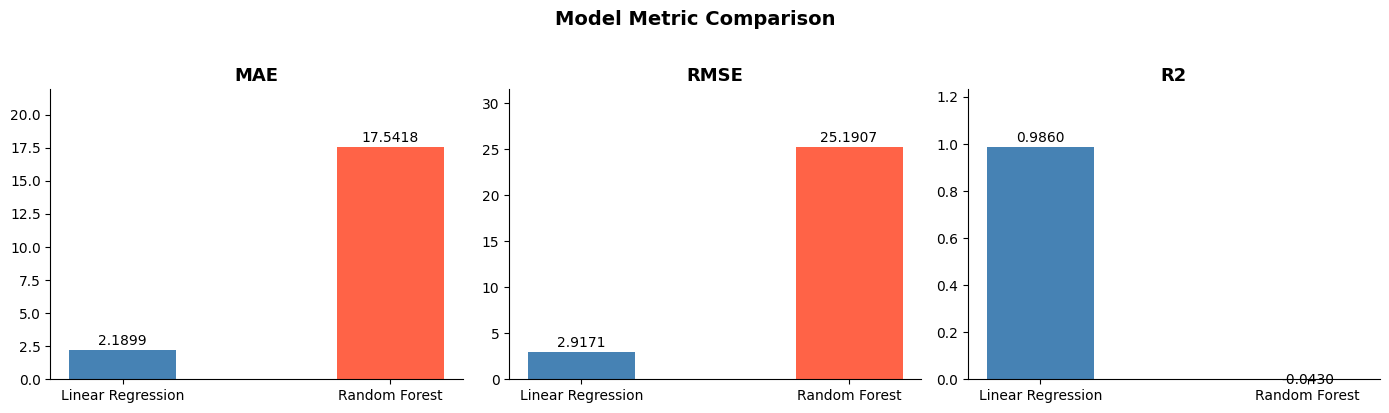

 Figure saved: eval_metric_comparison.png


In [14]:
# ── 7.1 Bar chart: Metric Comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics   = ['MAE', 'RMSE', 'R2']
labels    = ['Linear Regression', 'Random Forest']
colors    = ['steelblue', 'tomato']

for i, metric in enumerate(metrics):
    vals = [lr_results[metric], rf_results[metric]]
    bars = axes[i].bar(labels, vals, color=colors, width=0.4)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, max(vals) * 1.25)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01 * max(vals),
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Metric Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: eval_metric_comparison.png')

---
## 📉 Section 8: Actual vs Predicted Closing Prices

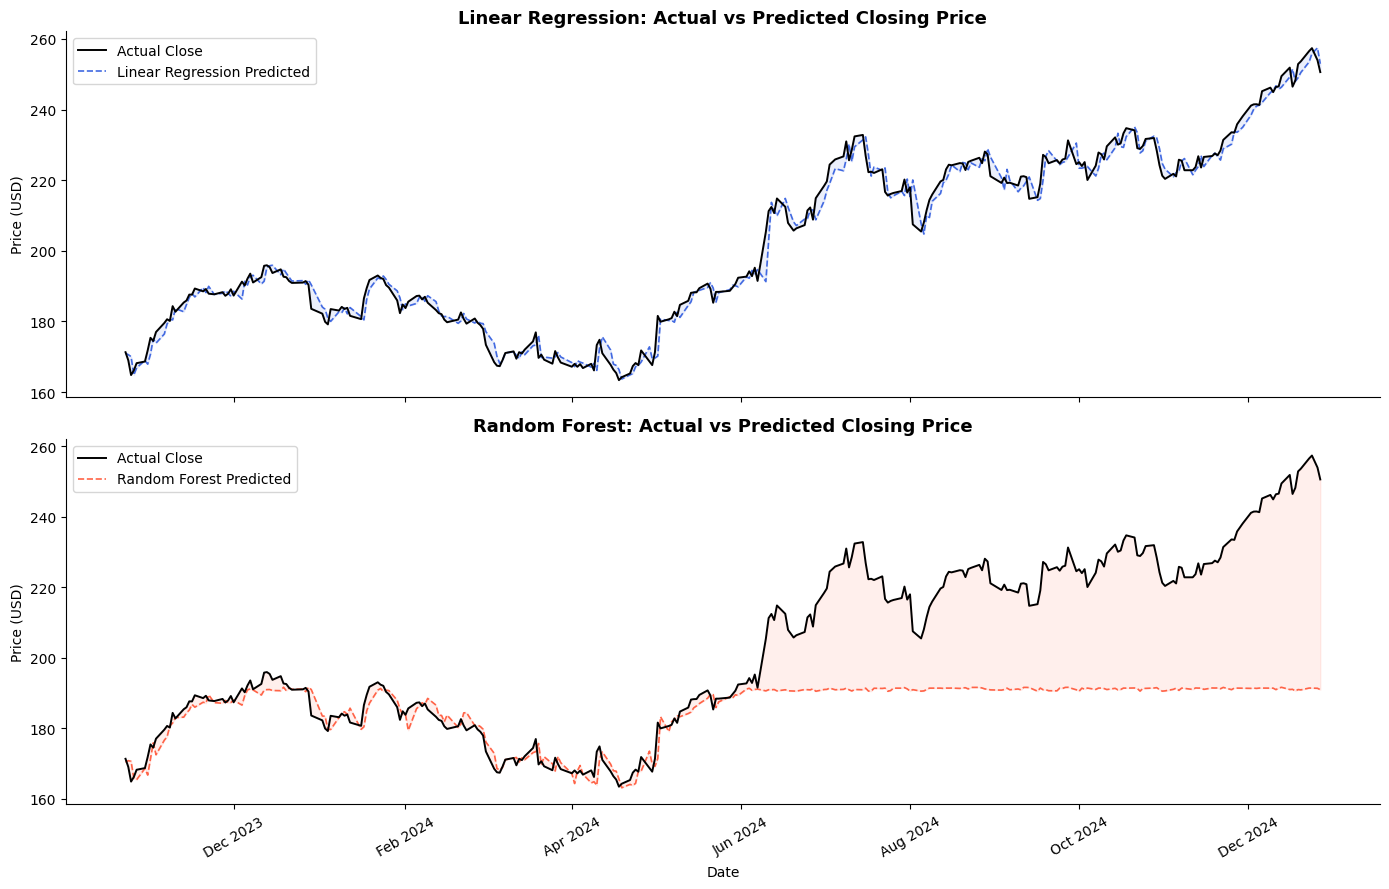

  Figure saved: predictions_full.png


In [15]:
# ── 8.1 Full Test Period: Actual vs Both Models ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, preds, model_name, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['royalblue', 'tomato']
):
    ax.plot(dates_test, y_test,  color='black',  linewidth=1.4,
            label='Actual Close', zorder=3)
    ax.plot(dates_test, preds,   color=color,    linewidth=1.2,
            linestyle='--', label=f'{model_name} Predicted', zorder=2)
    ax.fill_between(dates_test, y_test, preds, alpha=0.1, color=color)
    ax.set_title(f'{model_name}: Actual vs Predicted Closing Price', fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

axes[1].set_xlabel('Date')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('predictions_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved: predictions_full.png')

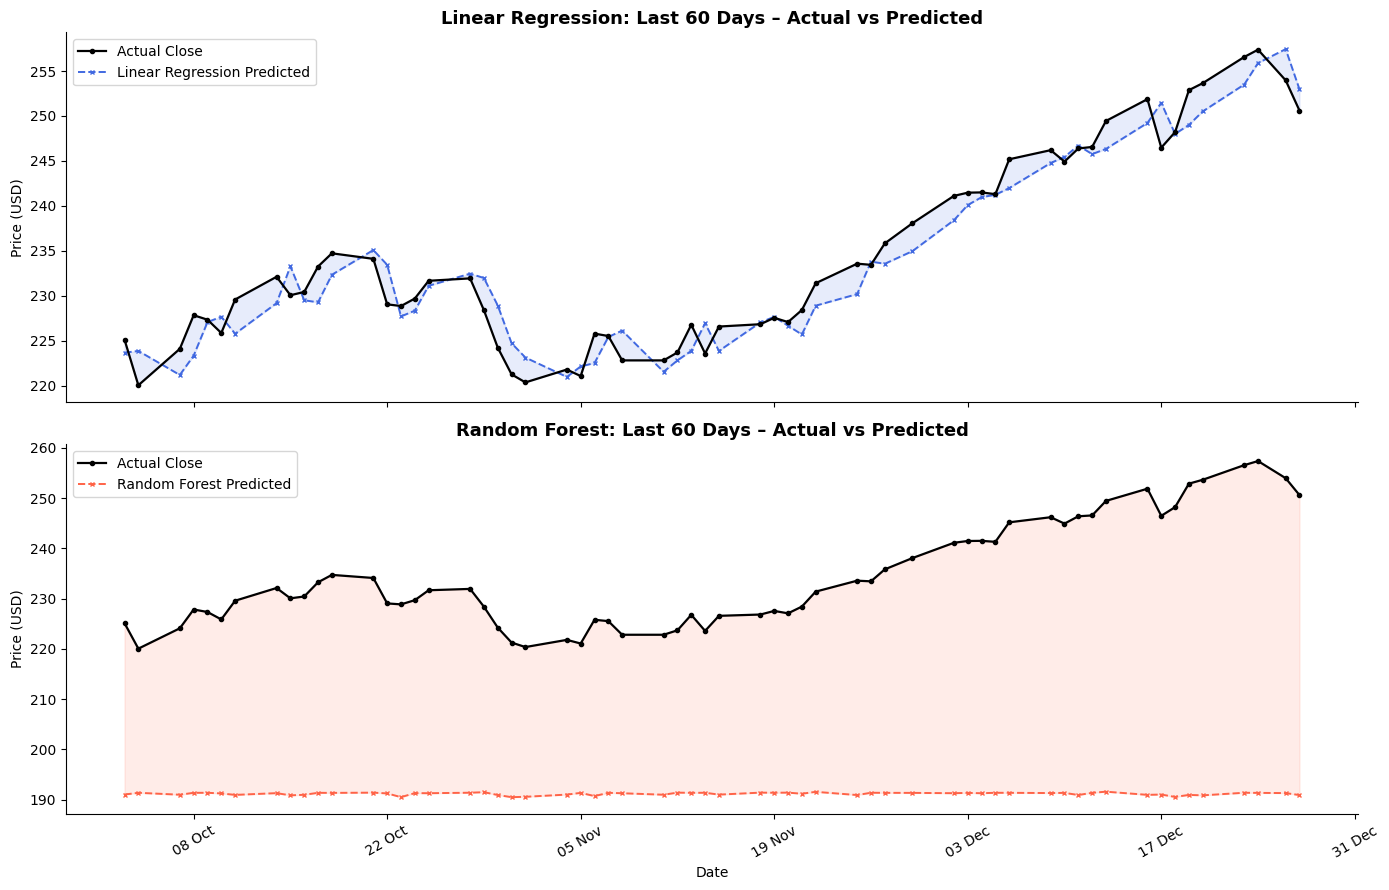

 Figure saved: predictions_zoom.png


In [16]:
# ── 8.2 Zoomed View: Last 60 Test Days ────────────────────────────────────────
n = 60
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, preds, model_name, color in zip(
    axes,
    [lr_preds[-n:], rf_preds[-n:]],
    ['Linear Regression', 'Random Forest'],
    ['royalblue', 'tomato']
):
    ax.plot(dates_test[-n:], y_test[-n:], color='black', linewidth=1.6,
            label='Actual Close', marker='o', markersize=3, zorder=3)
    ax.plot(dates_test[-n:], preds, color=color, linewidth=1.4,
            linestyle='--', label=f'{model_name} Predicted',
            marker='x', markersize=3, zorder=2)
    ax.fill_between(dates_test[-n:], y_test[-n:], preds, alpha=0.12, color=color)
    ax.set_title(f'{model_name}: Last {n} Days – Actual vs Predicted', fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))

axes[1].set_xlabel('Date')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('predictions_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: predictions_zoom.png')

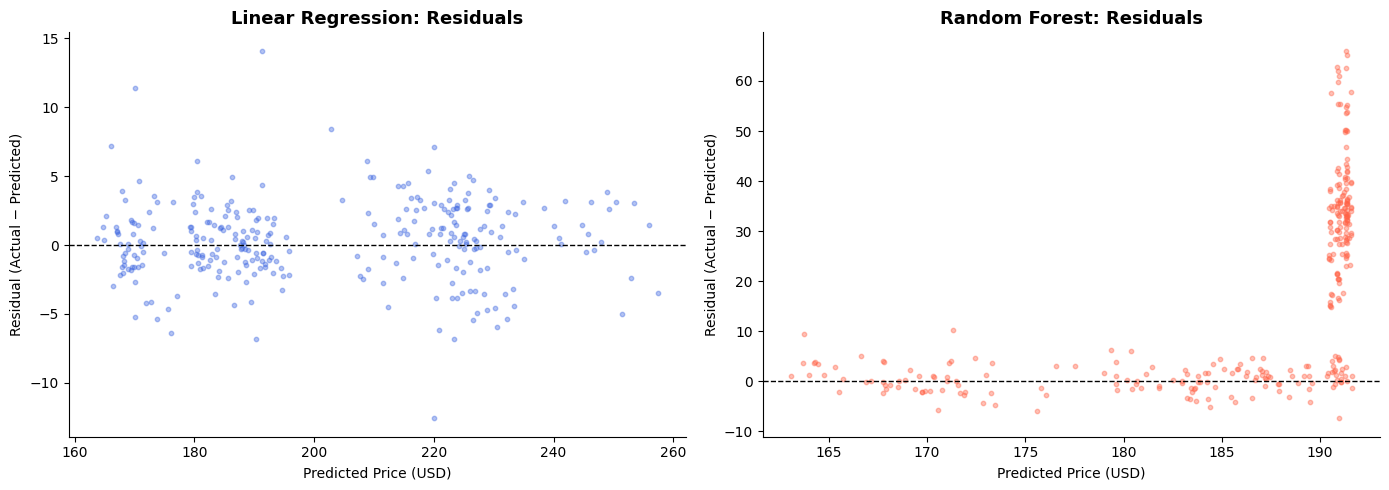

  Figure saved: eval_residuals.png


In [17]:
# ── 8.3 Residual Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['royalblue', 'tomato']
):
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.4, s=10, color=color)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f'{name}: Residuals', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Price (USD)')
    ax.set_ylabel('Residual (Actual − Predicted)')

plt.tight_layout()
plt.savefig('eval_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved: eval_residuals.png')

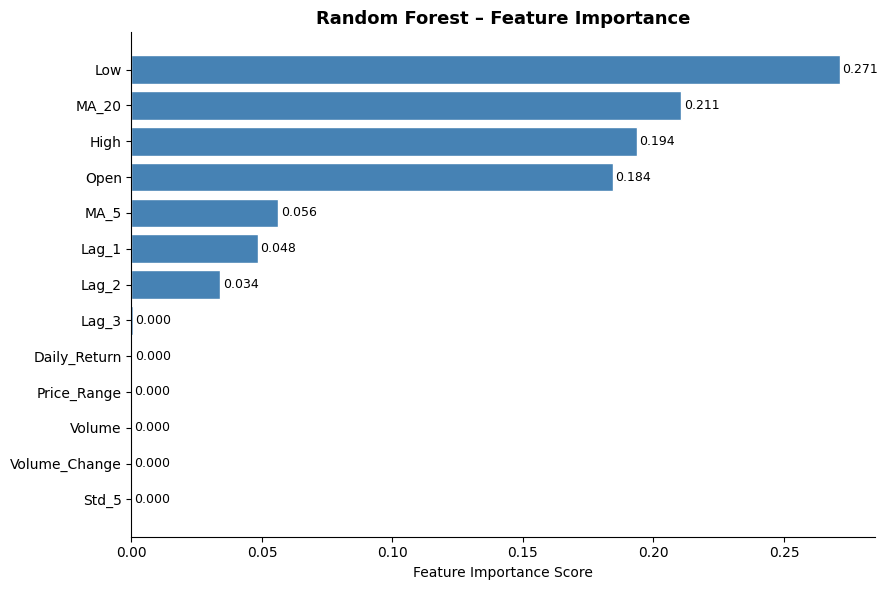

 Figure saved: feature_importance.png


In [18]:
# ── 8.4 Feature Importance (Random Forest) ────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance Score')
ax.set_title('Random Forest – Feature Importance', fontsize=13, fontweight='bold')
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: feature_importance.png')

---
## 🔮 Section 9: Predict Next Day's Closing Price

In [19]:
def predict_next_day(model, scaler, df_features: pd.DataFrame,
                     feature_cols: list) -> float:
    """Use the last available row to predict the NEXT day's closing price."""
    last_row = df_features[feature_cols].iloc[-1].values.reshape(1, -1)
    last_row_scaled = scaler.transform(last_row)
    return model.predict(last_row_scaled)[0]


last_actual_date  = df.index[-1]
last_actual_close = df['Close'].iloc[-1]

lr_next = predict_next_day(lr_model, scaler, df, FEATURES)
rf_next = predict_next_day(rf_model, scaler, df, FEATURES)

print('═' * 50)
print('       NEXT TRADING DAY PREDICTION')
print('═' * 50)
print(f'  Last known date     : {last_actual_date.date()}')
print(f'  Last Close price    : ${last_actual_close:.2f}')
print(f'  LR  Predicted Close : ${lr_next:.2f}  '
      f'({(lr_next - last_actual_close)/last_actual_close*100:+.2f}%)')
print(f'  RF  Predicted Close : ${rf_next:.2f}  '
      f'({(rf_next - last_actual_close)/last_actual_close*100:+.2f}%)')
print('═' * 50)

══════════════════════════════════════════════════
       NEXT TRADING DAY PREDICTION
══════════════════════════════════════════════════
  Last known date     : 2024-12-27
  Last Close price    : $253.97
  LR  Predicted Close : $252.97  (-0.39%)
  RF  Predicted Close : $190.90  (-24.83%)
══════════════════════════════════════════════════


## 💡 Section 10: Results & Final Insights

### Key Findings

1. **Linear Regression outperformed Random Forest** — achieving an R² of 0.98
   compared to Random Forest's negative R². This was an unexpected but
   insightful result that reveals an important limitation of tree-based
   models on time series data.

2. **Random Forest failed to extrapolate** — stock prices in the test period
   (2024) exceeded the price range seen during training. Since Random Forest
   can only predict within the range of values it was trained on, it struggled
   badly when prices moved beyond that boundary. This is a known limitation of
   ensemble tree models on time series forecasting.

3. **Linear Regression handled unseen price ranges well** — because it fits a
   line through data, it naturally extrapolates beyond training values, making
   it more suitable for trending time series like stock prices.

4. **Lag features dominated importance** — `Lag_1` (yesterday's closing price)
   was the strongest predictor, reflecting the well-known **autocorrelation**
   in stock price time series — recent prices are the strongest signal for
   tomorrow's price.

5. **Moving averages added value** — `MA_5` and `MA_20` ranked highly in
   feature importance, confirming that short and medium-term trend signals
   are useful predictors.

### Limitations
- Models use only **technical (price/volume) features**. Adding sentiment
  data (news, social media) and **macroeconomic indicators** (interest rates,
  CPI) could improve accuracy.
- The next-day prediction assumes markets behave similarly to the past.
  **Black swan events** (COVID-19, banking crises) are inherently difficult
  to forecast.
- **Random Forest is not suitable** for trending time series without
  additional techniques like detrending or walk-forward validation.
- These predictions should **NOT be used for actual trading decisions**
  without further risk management.

### Future Improvements
- Try **LSTM / GRU** (deep learning) models designed for sequential data
- Add **sentiment analysis** from financial news APIs
- Incorporate **macro features**: VIX index, treasury yields, sector ETF
  performance
- Implement **walk-forward validation** (rolling retraining window) to fix
  the Random Forest extrapolation problem
- Apply **detrending** to the data before training Random Forest so it
  doesn't hit the range boundary issue

In [20]:
# ── Final Summary Table ────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Metric': 'MAE  (↓ better)', 'Linear Regression': f"${lr_results['MAE']:.4f}",
     'Random Forest': f"${rf_results['MAE']:.4f}"},
    {'Metric': 'RMSE (↓ better)', 'Linear Regression': f"${lr_results['RMSE']:.4f}",
     'Random Forest': f"${rf_results['RMSE']:.4f}"},
    {'Metric': 'R²   (↑ better)', 'Linear Regression': f"{lr_results['R2']:.4f}",
     'Random Forest': f"{rf_results['R2']:.4f}"},
])

print('\n' + '═'*55)
print('          📊 FINAL MODEL COMPARISON SUMMARY')
print('═'*55)
print(summary.to_string(index=False))
print('═'*55)
print('\n🏆 Winner: Linear Regression')
print('   Random Forest failed to extrapolate beyond training price range')
print('\n✅ Notebook complete!')


═══════════════════════════════════════════════════════
          📊 FINAL MODEL COMPARISON SUMMARY
═══════════════════════════════════════════════════════
         Metric Linear Regression Random Forest
MAE  (↓ better)           $2.1899      $17.5418
RMSE (↓ better)           $2.9171      $25.1907
R²   (↑ better)            0.9860       -0.0430
═══════════════════════════════════════════════════════

🏆 Winner: Linear Regression
   Random Forest failed to extrapolate beyond training price range

✅ Notebook complete!
